# Trabajo Práctico: Entrega EDA
## Detección de Duración Anómala de Vuelos Comerciales

**Universidad del Gran Rosario — Licenciatura en Ciencia de Datos**
**Grupo 32:** Luis Gomez Morales · Mariano Tejerina · Emiliano Quiroga · Leandro Bonifacio

---
## 1. Introducción

### Dominio de aplicación
Aviación comercial doméstica en Argentina. La eficiencia operativa del sector impacta en la satisfacción de los pasajeros y en el rendimiento económico de aerolíneas y administradores de aeropuertos. Factores climáticos y fricciones operativas (patrones de espera, desvíos, rodaje lento) hacen que el tiempo real de un vuelo supere con frecuencia lo esperable.

### Alcance
Vuelos **domésticos** (cabotaje) con **Aeroparque Jorge Newbery (AER)** como origen o destino. En el dataset de ANAC utilizado (2019–2026), el **64 %** de los movimientos domésticos comerciales involucra a AER y acotar el alcance a este aeropuerto permite cruzar los datos con **una única estación meteorológica** de referencia.

### Objetivo del modelo
Predecir, como problema de **clasificación binaria**, si un vuelo tendrá una **duración anómala**, es decir, si su duración real supera el **percentil 90 histórico de su ruta** (umbral empírico por ruta, no un valor fijo, para adaptarse a la variabilidad entre rutas cortas y largas).

> **Particularidad metodológica.** El dataset de ANAC no incluye el horario programado, por lo que no se puede medir "demora respecto de lo planificado". En su lugar se mide la *anomalía respecto del comportamiento histórico de cada ruta*, que es un problema estadístico distinto, definido a partir de una limitación real de la fuente.

### Beneficios esperados
- Identificar cuellos de botella de forma preventiva.
- Ayudar a operaciones a optimizar **conexiones de pasajeros**.
- Mejorar la gestión de **tripulaciones y recursos en tierra**.

### Fuentes de datos
| Fuente | Contenido | Uso |
|---|---|---|
| **ANAC** | Aterrizajes y despegues (fecha/hora UTC, aeropuerto, origen/destino, aerolínea, modelo de aeronave, pasajeros, clase de vuelo) | Construcción de vuelos, duración y target |
| **SMN** | Datos meteorológicos **diarios** por estación (temperaturas, precipitación, viento, presión, humedad, nubosidad) | Variables climáticas en AER |

**Acceso a los datos originales**
- ANAC – Aterrizajes y despegues: https://datos.gob.ar/dataset/aterrizajes-y-despegues-procesados-por-la-administracion-nacional-de-aviacion-civil-anac
- SMN – Datos diarios por estación: https://www.smn.gob.ar/descarga-de-datos

**Período de los datos**
| Conjunto | Desde | Hasta |
|---|---|---|
| ANAC (crudo) | 01/01/2019 | 31/08/2026 |
| SMN – estación Aeroparque Aero | 01/01/2021 | 31/07/2026 |
| **Dataset final (limpio)** | **15/03/2021** | **31/07/2026** |

El período efectivo queda determinado por dos motivos: el SMN disponible comienza en 2021, y AER estuvo cerrado por obras entre el 01/08/2020 y el 15/03/2021.

### Estructura del notebook
| Contenido | Sección |
|---|---|
| Introducción: dominio, beneficios y objetivo | 1 |
| Configuración y carga de datos | 2 |
| Análisis Exploratorio de Datos | 3 (datos crudos) y 6 (datos limpios) |
| Justificación de limpieza y preprocesamiento | 4 y 5 |
| Descripción del dataset luego de la limpieza | 6 |
| Acceso al dataset limpio | 7 |
| Modelo de AA propuesto y justificación | 8 |

## 2. Configuración y carga de datos
Se definen los parámetros del trabajo y se cargan las dos fuentes: los archivos anuales de ANAC (2019–2026) y el archivo del SMN con registros diarios por estación (2021–2026).

In [23]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Fuera de Colab: se usan rutas locales.")

import unicodedata

def arreglar(s):
    # Corrige "mojibake" (UTF-8 leído como cp1252/latin-1): 'DomÃ©stico' -> 'Doméstico'
    if isinstance(s, str) and ("Ã" in s or "Â" in s):
        for enc in ("cp1252", "latin-1"):
            try:
                return s.encode(enc).decode("utf-8")
            except (UnicodeEncodeError, UnicodeDecodeError):
                continue
    return s

def norm(s):
    # minúsculas, sin acentos, sin espacios sobrantes: para comparar nombres de columnas
    s = unicodedata.normalize("NFKD", arreglar(str(s)))
    return s.encode("ascii", "ignore").decode().lower().strip()

# ----------------------------- PARÁMETROS -----------------------------
# Descarga los datos del repositorio (Colab solo abre el notebook, no los archivos de datos)
!test -d /content/repo || git clone https://github.com/erquiroga/ar_2026.git /content/repo

# Carpeta con los archivos: se usa la primera que exista y tenga datos (repo clonado, Drive o sesión de Colab)
CANDIDATOS = ["/content/repo/data", "/content/drive/MyDrive/TP_vuelos", "/content"]
DATA_DIR = next((d for d in CANDIDATOS if glob.glob(os.path.join(d, "ad20*"))), "/content")
print("DATA_DIR =", DATA_DIR)
ANAC_GLOBS = [os.path.join(DATA_DIR, "ad20*")]
SMN_GLOB  = os.path.join(DATA_DIR, "smn*")               # archivo(s) del SMN (cualquier extensión)
OUT_PATH  = os.path.join(DATA_DIR, "dataset_limpio.csv") # salida: dataset limpio

# clave interna -> nombre de la columna en el CSV de ANAC
COLS_ANAC = {
    "fecha":      "Fecha UTC",
    "hora":       "Hora UTC",
    "clase":      "Clase de Vuelo (todos los vuelos)",
    "clasif":     "Clasificación Vuelo",
    "tipo":       "Tipo de Movimiento",
    "aeropuerto": "Aeropuerto",
    "orig_dest":  "Origen / Destino",
    "aerolinea":  "Aerolinea Nombre",
    "aeronave":   "Aeronave",     # OJO: en ANAC es el MODELO del avión, no la matrícula
    "pasajeros":  "Pasajeros",
}

AP_REF         = "AER"          # código del aeropuerto de referencia en ANAC
ESTACION_SMN   = "AEROPARQUE"   # texto que identifica la estación en el SMN
SMN_NA         = ["", "NA", "-99.9", "-999", "-9999", "S/D"]
UTC_A_LOCAL    = pd.Timedelta(hours=-3)   # Argentina = UTC-3

MIN_DUR, MAX_DUR  = 20, 300     # minutos: rango de duración plausible para cabotaje
FACTOR_MIN, FACTOR_MAX = 0.5, 2.0  # duración válida = [0.5, 2.0] x mediana de su ruta (descarta emparejamientos erróneos)
USAR_PAX_EN_CLAVE = None        # None = decidir automáticamente (ver Sección 4); True/False para forzar
MIN_VUELOS_RUTA   = 30          # mínimo de vuelos de entrenamiento para fijar el umbral de una ruta
PCT_ANOMALO       = 0.90        # percentil que define la anomalía
FRAC_TRAIN        = 0.80        # fracción temporal usada para calcular umbrales y entrenar
SEED              = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR = /content


In [27]:
def leer_csv_anac(path):
    # Prueba dos codificaciones y detecta el separador mirando el encabezado
    for enc in ("utf-8-sig", "latin-1"):
        try:
            with open(path, encoding=enc) as f:
                cab = f.readline()
            sep = max([";", ",", "\t"], key=cab.count)
            df = pd.read_csv(path, sep=sep, encoding=enc, dtype=str)
            df.columns = [arreglar(c).strip() for c in df.columns]
            df["archivo"] = os.path.basename(path)
            return df
        except UnicodeDecodeError:
            continue
    raise ValueError(f"No se pudo leer {path}")

files = sorted(f for g in ANAC_GLOBS for f in glob.glob(g))
assert files, f"No se encontraron archivos de ANAC en {DATA_DIR}"

partes = [leer_csv_anac(f) for f in files]

resumen = pd.DataFrame({
    "archivo": [p["archivo"].iloc[0] for p in partes],
    "filas": [len(p) for p in partes],
    "columnas": [p.shape[1] - 1 for p in partes],
})
display(resumen)

raw = pd.concat(partes, ignore_index=True)

mapa = {norm(c): c for c in raw.columns}
faltan = [v for v in COLS_ANAC.values() if norm(v) not in mapa]
assert not faltan, f"Columnas no encontradas: {faltan}. Disponibles: {list(raw.columns)}"

print("\nDimensiones del dataset crudo de ANAC:", raw.shape)
display(raw.head())
print("\nColumnas comunes a todos los archivos:", list(partes[0].columns[:-1]))

,archivo,filas,columnas
0,ad2019,580764,12
1,ad2020,212726,12
2,ad2021,329781,12
3,ad2022,106949,12
4,ad2023,557152,12
5,ad2024,578602,12
6,ad2025,597784,12
7,ad2026,371802,13



Dimensiones del dataset crudo de ANAC: (3335560, 14)


,Fecha UTC,Hora UTC,Clase de Vuelo (todos los vuelos),Clasificación Vuelo,Tipo de Movimiento,Aeropuerto,Origen / Destino,Aerolinea Nombre,Aeronave,Pasajeros,PAX,Calidad dato,archivo,Matrícula
0,01/01/2019,0:01,Regular,Domestico,ATERRIZAJE,EZE,SAL,AEROLINEAS ARGENTINAS SA,0,"44,00","22,00",DEFINITIVO,ad2019,NaN
1,01/01/2019,0:01,Regular,Internacional,ATERRIZAJE,EZE,SBGL,TRANSPORTES AEREOS DEL MERCOSUR,0,"165,00","165,00",DEFINITIVO,ad2019,NaN
2,01/01/2019,0:03,Regular,Domestico,ATERRIZAJE,AER,SIS,AUSTRAL LINEAS AEREAS-CIELOS DEL SUR S.A,0,"11,00","5,50",DEFINITIVO,ad2019,NaN
3,01/01/2019,0:04,Regular,Internacional,ATERRIZAJE,EZE,SBGR,TRANSPORTES AEREOS DEL MERCOSUR,0,"69,00","69,00",DEFINITIVO,ad2019,NaN
4,01/01/2019,0:06,Regular,Internacional,ATERRIZAJE,AER,SBGR,LAN ARGENTINA S.A. (LATAM AIRLINES),0,"53,00","53,00",DEFINITIVO,ad2019,NaN



Columnas comunes a todos los archivos: ['Fecha UTC', 'Hora UTC', 'Clase de Vuelo (todos los vuelos)', 'Clasificación Vuelo', 'Tipo de Movimiento', 'Aeropuerto', 'Origen / Destino', 'Aerolinea Nombre', 'Aeronave', 'Pasajeros', 'PAX', 'Calidad dato']


In [28]:
def leer_smn(path):
    # Archivo separado por tabulaciones; la primera línea viene vacía y pandas la saltea sola
    w = pd.read_csv(path, sep="\t", dtype=str, encoding="latin-1")
    w.columns = [c.strip().upper() for c in w.columns]
    for c in w.columns:
        w[c] = w[c].str.strip()
    return w

smn_files = sorted(glob.glob(SMN_GLOB))
assert smn_files, f"No se encontraron archivos del SMN en {DATA_DIR}"

partes_smn = [leer_smn(f) for f in smn_files]
resumen_smn = pd.DataFrame({
    "archivo": [os.path.basename(f) for f in smn_files],
    "filas": [len(p) for p in partes_smn],
    "columnas": [p.shape[1] for p in partes_smn],
})
display(resumen_smn)

smn_all = pd.concat(partes_smn, ignore_index=True)
print("\nDimensiones del dataset crudo del SMN:", smn_all.shape)
display(smn_all.head())
print("\nColumnas:", list(smn_all.columns))

,archivo,filas,columnas
0,smn_datos_meteorologicos_desde_2021.lst,182489,14



Dimensiones del dataset crudo del SMN: (182489, 14)


,NRO_OMM,NOMBRE,FECHA,TMAX,TMIN,TMEDIA,PRECIP,HELIOF,VTO_MDIR,VTO_MVEL,VEL_MED,PRE_EST,HUM_REL,NUB_TOT
0,87007,LA QUIACA OBSERVATORIO,01/01/2021,24,8.2,15.5,,11.9,9,15,5,671.9,60,2
1,87007,LA QUIACA OBSERVATORIO,02/01/2021,22,9.2,14.5,2,7.6,23,33,6,671.6,64,4
2,87007,LA QUIACA OBSERVATORIO,03/01/2021,24.8,7.5,14.5,6,10.9,5,24,8,668.9,64,3
3,87007,LA QUIACA OBSERVATORIO,04/01/2021,17,5.2,10.7,5,6.6,5,15,5,667.7,74,5
4,87007,LA QUIACA OBSERVATORIO,05/01/2021,16.7,5,9.5,2,6.7,23,15,6,669.4,74,7



Columnas: ['NRO_OMM', 'NOMBRE', 'FECHA', 'TMAX', 'TMIN', 'TMEDIA', 'PRECIP', 'HELIOF', 'VTO_MDIR', 'VTO_MVEL', 'VEL_MED', 'PRE_EST', 'HUM_REL', 'NUB_TOT']


## 3. Análisis Exploratorio de Datos (datos crudos)
Se examina la estructura, la calidad y las distribuciones principales **antes** de limpiar, para justificar cada decisión de preprocesamiento.

In [31]:
# Preparación mínima para poder explorar: se seleccionan las columnas, se corrige la codificación
# y se convierten tipos (fecha+hora y pasajeros). La limpieza propiamente dicha se hace en la Sección 4.
inv = {mapa[norm(v)]: k for k, v in COLS_ANAC.items()}
anac = raw.rename(columns=inv)[list(COLS_ANAC)].copy()

def limpiar_texto(s):
    cache = {u: (arreglar(u).strip() if isinstance(u, str) else u) for u in s.dropna().unique()}
    return s.map(cache).replace({"": np.nan})

for c in ["clase", "clasif", "tipo", "aeropuerto", "orig_dest", "aerolinea", "aeronave"]:
    anac[c] = limpiar_texto(anac[c].astype("object"))

anac["pasajeros"] = pd.to_numeric(anac["pasajeros"].astype("object").str.replace(",", ".", regex=False), errors="coerce")
anac["dt"] = pd.to_datetime(anac["fecha"].astype(str) + " " + anac["hora"].astype(str),
                            dayfirst=True, errors="coerce")

print(f"Rango temporal: {anac['dt'].min()}  ->  {anac['dt'].max()}")
print(f"Fechas/horas no interpretables: {anac['dt'].isna().sum()}\n")

nulos = anac.isna().mean().mul(100).round(2).sort_values(ascending=False).rename("% nulos")
display(nulos.to_frame())

for c in ["clasif", "tipo", "clase"]:
    print(f"\n--- {c} ---")
    print(anac[c].value_counts(dropna=False).head(12))

Rango temporal: 2019-01-01 00:01:00  ->  2026-08-31 23:57:00
Fechas/horas no interpretables: 0



,% nulos
aerolinea,5.47
hora,0.00
fecha,0.00
clase,0.00
clasif,0.00
aeropuerto,0.00
tipo,0.00
orig_dest,0.00
aeronave,0.00
pasajeros,0.00



--- clasif ---
clasif
Doméstico        2236039
Internacional     623615
Domestico         475906
Name: count, dtype: int64

--- tipo ---
tipo
Despegue      1386797
Aterrizaje    1367998
DESPEGUE       291590
ATERRIZAJE     289174
NaN                 1
Name: count, dtype: int64

--- clase ---
clase
Regular                                   1888840
Vuelo Privado con Matrícula Nacional       476260
Vuelo Escuela                              454512
No Regular                                 264681
Vuelo Oficial Nacional                     184171
Vuelo Privado con Matrícula Extranjera      27286
Vuelo de Adiestramiento                     24976
Trabajo Aéreo                               11844
Vuelo Oficial Extranjero                     2990
Name: count, dtype: int64


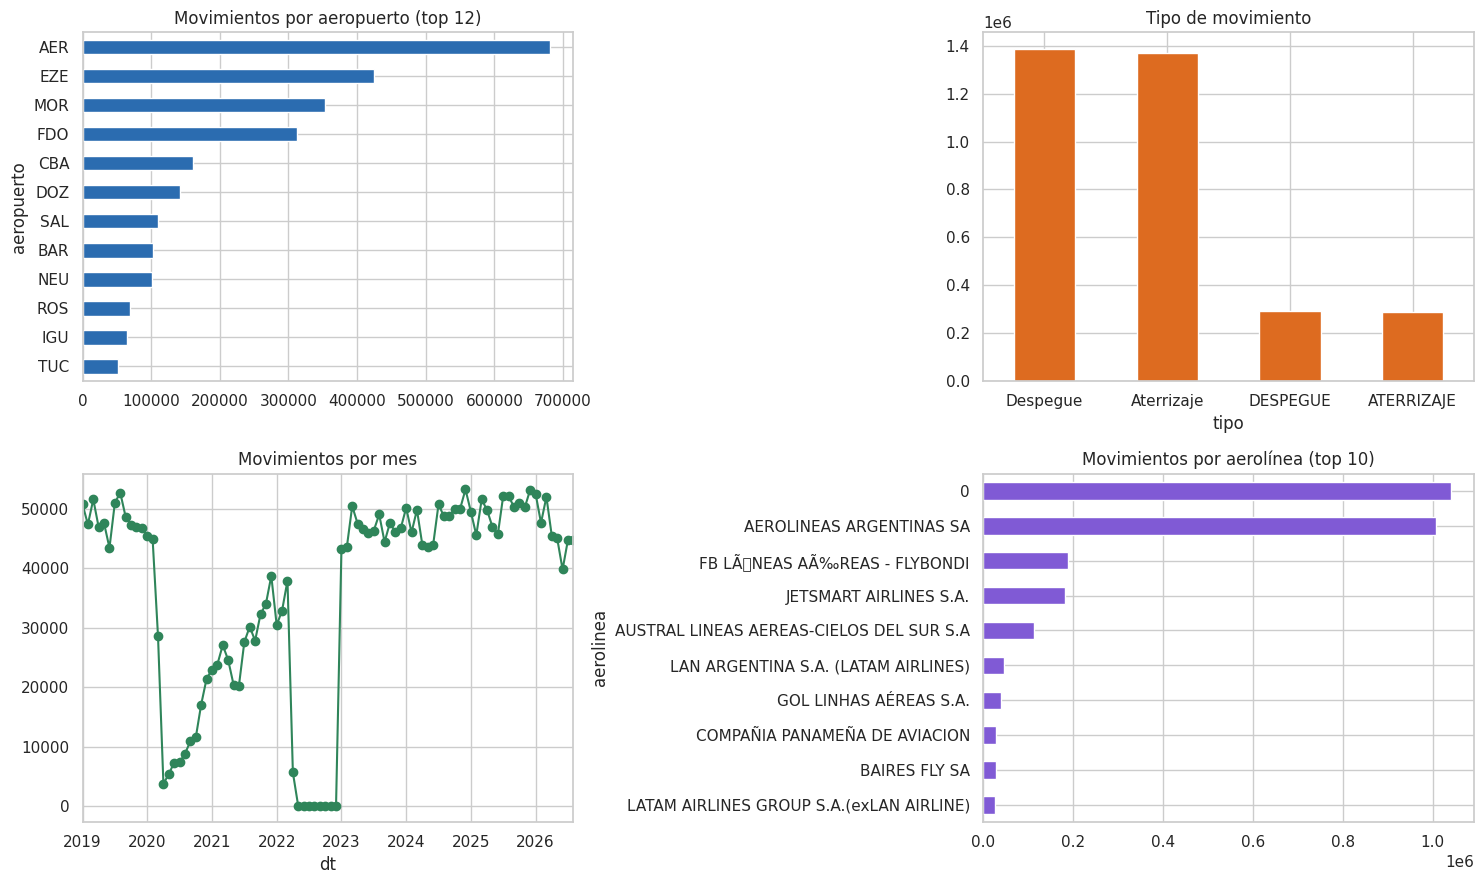

In [37]:
# Distribuciones principales del crudo de ANAC: aeropuertos, tipo de movimiento, evolución mensual y aerolíneas
fig, ax = plt.subplots(2, 2, figsize=(15, 9))

anac["aeropuerto"].value_counts().head(12).sort_values().plot.barh(ax=ax[0, 0], color="#2b6cb0")
ax[0, 0].set_title("Movimientos por aeropuerto (top 12)")

anac["tipo"].value_counts().plot.bar(ax=ax[0, 1], color="#dd6b20", rot=0)
ax[0, 1].set_title("Tipo de movimiento")

(anac.dropna(subset=["dt"]).set_index("dt").resample("MS").size()
     .plot(ax=ax[1, 0], marker="o", color="#2f855a"))
ax[1, 0].set_title("Movimientos por mes")

anac["aerolinea"].value_counts().head(10).sort_values().plot.barh(ax=ax[1, 1], color="#805ad5")
ax[1, 1].set_title("Movimientos por aerolínea (top 10)")

plt.tight_layout(); plt.show()

In [39]:
# Columna 'Aeronave': ¿identifica un avión individual (matrícula) o un modelo?
print("Valores distintos de 'aeronave':", anac["aeronave"].nunique())
print(anac["aeronave"].value_counts().head(10))
print(f"\nRegistros con aeronave = '0' (sin informar): {(anac['aeronave'] == '0').mean():.1%}")

# ¿Hay una columna de matrícula? % de registros con dato, por archivo
print("\n% de registros con matrícula informada, por archivo:")
print(raw[mapa["matricula"]].notna().groupby(raw["archivo"]).mean().mul(100).round(1))

print("\nPasajeros por movimiento:")
display(anac["pasajeros"].describe().to_frame().T)
print(f"Movimientos con 0 pasajeros: {(anac['pasajeros'] == 0).mean():.1%} | sin dato: {anac['pasajeros'].isna().mean():.1%}")

print("\n% de registros con aeronave = '0' y con 0 pasajeros, por archivo:")
display(pd.DataFrame({"aeronave_0": anac["aeronave"] == "0", "pasajeros_0": anac["pasajeros"] == 0})
          .groupby(raw["archivo"]).mean().mul(100).round(1))

Valores distintos de 'aeronave': 982
aeronave
0                   1244441
EMB-ERJ190100IGW     330557
AIB-A320-232         124262
BO-737-8              83305
BO-737-800            78138
CE-152                63699
CE-150-M              60805
CE-150-L              56036
BO-737-8Q8            55394
BO-B737-800           55141
Name: count, dtype: int64

Registros con aeronave = '0' (sin informar): 37.3%

% de registros con matrícula informada, por archivo:
archivo
ad2019      0.0
ad2020      0.0
ad2021      0.0
ad2022      0.0
ad2023      0.0
ad2024      0.0
ad2025      0.0
ad2026    100.0
Name: Matrícula, dtype: float64

Pasajeros por movimiento:


,count,mean,std,min,25%,50%,75%,max
pasajeros,3335559.0,76.40849,77.451567,0.0,0.0,76.0,148.0,953.0


Movimientos con 0 pasajeros: 34.7% | sin dato: 0.0%

% de registros con aeronave = '0' y con 0 pasajeros, por archivo:


,aeronave_0,pasajeros_0
archivo,,
ad2019,100.0,30.4
ad2020,85.3,48.1
ad2021,14.1,52.0
ad2022,13.7,37.1
ad2023,15.6,30.1
ad2024,17.0,34.4
ad2025,22.7,31.5
ad2026,26.8,29.9


Registros de la estación 'AEROPARQUE': 2038 | estaciones: ['AEROPARQUE AERO']

Período SMN: 2021-01-01 00:00:00 -> 2026-07-31 00:00:00


,count,mean,std,min,25%,50%,75%,max
tmax,2038.0,22.033072,5.973350,5.7,17.1,22.25,26.700,38.5
tmin,2038.0,14.799313,5.485866,1.4,10.3,14.80,19.100,28.3
tmedia,2038.0,18.287586,5.514161,4.4,13.7,18.40,22.900,32.3
precip,657.0,8.455403,15.773823,0.0,0.0,2.00,9.000,112.0
helio,1707.0,7.251611,3.901790,0.0,4.4,8.40,10.000,13.8
vto_dir,2038.0,15.745339,9.788205,1.0,9.0,12.00,21.000,36.0
vto_max,2038.0,36.964671,10.262616,13.0,30.0,35.00,43.000,104.0
vel_med,2038.0,13.695780,5.456814,3.0,10.0,13.00,17.000,40.0
pre_est,2038.0,1015.372964,6.091918,995.8,1011.0,1015.10,1019.275,1034.2
hum_rel,2038.0,70.772816,12.426195,28.0,62.0,71.00,80.000,100.0



% nulos:
 fecha_clima     0.00
tmax            0.00
tmin            0.00
tmedia          0.00
precip         67.76
helio          16.24
vto_dir         0.00
vto_max         0.00
vel_med         0.00
pre_est         0.00
hum_rel         0.00
nub_tot         0.00
dtype: float64


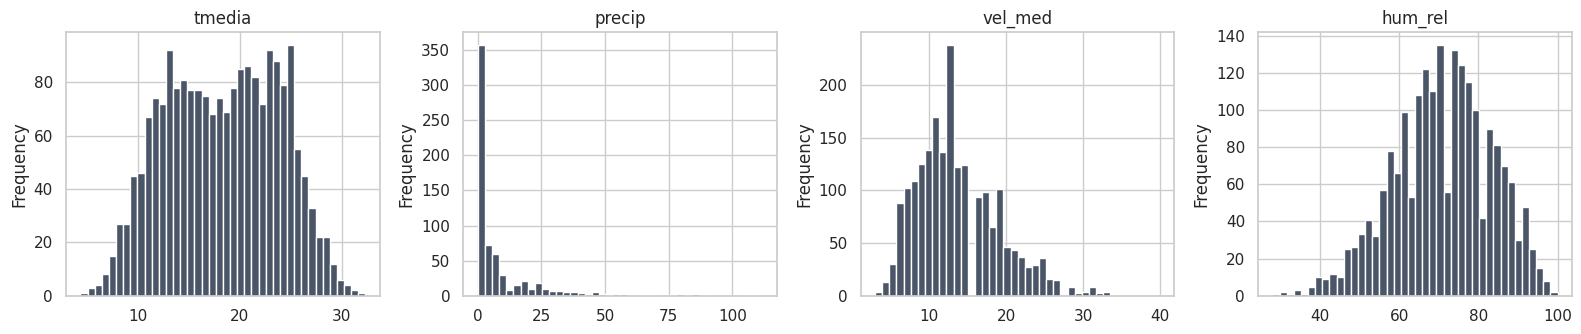

In [29]:
# EDA del clima (SMN): estación de referencia
smn_raw = smn_all[smn_all["NOMBRE"].str.upper().str.contains(ESTACION_SMN, na=False)].copy()
print(f"Registros de la estación '{ESTACION_SMN}':", len(smn_raw), "| estaciones:", list(smn_raw["NOMBRE"].unique()))

COLS_SMN = {"TMAX": "tmax", "TMIN": "tmin", "TMEDIA": "tmedia", "PRECIP": "precip", "HELIOF": "helio",
            "VTO_MDIR": "vto_dir", "VTO_MVEL": "vto_max", "VEL_MED": "vel_med",
            "PRE_EST": "pre_est", "HUM_REL": "hum_rel", "NUB_TOT": "nub_tot"}
smn_raw = smn_raw.rename(columns=COLS_SMN)
VARS_CLIMA = list(COLS_SMN.values())
for c in VARS_CLIMA:
    smn_raw[c] = pd.to_numeric(smn_raw[c].replace(SMN_NA, np.nan), errors="coerce")
smn_raw["fecha_clima"] = pd.to_datetime(smn_raw["FECHA"], dayfirst=True, errors="coerce")

print("\nPeríodo SMN:", smn_raw["fecha_clima"].min(), "->", smn_raw["fecha_clima"].max())
display(smn_raw[VARS_CLIMA].describe().T)
print("\n% nulos:\n", smn_raw[["fecha_clima"] + VARS_CLIMA].isna().mean().mul(100).round(2))

fig, ax = plt.subplots(1, 4, figsize=(16, 3.5))
for a, c in zip(ax, ["tmedia", "precip", "vel_med", "hum_rel"]):
    smn_raw[c].dropna().plot.hist(bins=40, ax=a, color="#4a5568"); a.set_title(c)
plt.tight_layout(); plt.show()

**Observaciones del EDA crudo (completar con los hallazgos de la corrida):**
- Calidad: porcentaje de nulos por columna, fechas inválidas y duplicados; codificación de caracteres defectuosa en algunas columnas (corregida al cargar).
- Composición: mezcla de vuelos domésticos e internacionales, regulares, no regulares y privados; solo una parte corresponde a AER.
- Cada vuelo aparece como **dos registros independientes** (un despegue y un aterrizaje). No hay número de vuelo, no hay matrícula (la columna `Aeronave` es el modelo) y no hay horario programado: hay que reconstruir los vuelos de otra manera.
- Clima: el SMN entrega **un registro por día** (no horario), con temperaturas, precipitación, viento, presión, humedad y nubosidad. **No incluye visibilidad**.

## 4. Limpieza y preprocesamiento (con justificación)

| # | Tarea | Justificación |
|---|---|---|
| 1 | Corregir codificación de texto, normalizar (espacios, mayúsculas) y parsear fecha+hora a `datetime` | Evita que "AER" y "AER " (o "Doméstico" y "DomÃ©stico") sean categorías distintas y permite ordenar cronológicamente. |
| 2 | Eliminar registros con fecha/hora inválida o sin tipo de movimiento, aeropuerto u origen/destino | Sin esos campos no se puede reconstruir el vuelo; imputarlos inventaría rutas. Las aerolíneas o modelos faltantes (`0`) se agrupan como `DESCONOCIDO`. |
| 3 | Eliminar duplicados exactos | Un mismo movimiento repetido generaría emparejamientos falsos. |
| 4 | Conservar solo vuelos **domésticos** de clase **regular / no regular** (excluir privados, trabajo aéreo, etc.) | El alcance es comercial doméstico; los vuelos privados tienen patrones operativos distintos y ensucian el histórico por ruta. |
| 5 | Quedarse con movimientos que involucran a **AER** | Define el alcance del TP y permite usar una sola estación meteorológica. Se hace *antes* de emparejar para reducir el volumen conservando ambos registros de cada vuelo. |
| 6 | **Emparejar** cada despegue con su aterrizaje usando ruta + aerolínea + modelo de aeronave (+ pasajeros si ambos registros lo comparten), en orden cronológico y con ventana de duración válida | No existe número de vuelo ni matrícula. Los aeropuertos de despegue y aterrizaje deben coincidir con el origen/destino informado. |
| 7 | Descartar duraciones fuera de `[MIN_DUR, MAX_DUR]` min o fuera de `[0.5, 2.0]` × la mediana de su ruta | Duraciones inverosímiles indican un emparejamiento incorrecto, no un vuelo anómalo real. El factor 2.0 deja lugar a anomalías verdaderas (que rondan +10 % a +50 %). |
| 8 | Clima: interpolación lineal de huecos de **hasta 2 días** (excepto precipitación) | Variables continuas de variación lenta; huecos largos no se rellenan para no inventar datos. La precipitación no se interpola porque un día seco no es el promedio de dos días lluviosos. |
| 9 | Join por **fecha local** entre el vuelo y el registro diario del SMN en AER | Alinea el vuelo con las condiciones del día en AER (ANAC está en UTC; se convierte a hora local UTC-3). |
| 10 | Target con umbral P90 por ruta **calculado solo con el período de entrenamiento** | Si el umbral se calculara con toda la historia, el test influiría en la definición del label (fuga de información). |

In [12]:
log = []
def registrar(desc, antes, despues):
    log.append({"paso": desc, "registros_antes": antes, "registros_despues": despues, "eliminados": antes - despues})

df = anac.copy()

# 1-2. Normalización y nulos clave
for c in ["aeropuerto", "orig_dest", "aerolinea", "aeronave"]:
    df[c] = df[c].map(lambda x: x.upper() if isinstance(x, str) else x)
df["aerolinea"] = df["aerolinea"].fillna("DESCONOCIDO")
df["aeronave"]  = df["aeronave"].replace({"0": "DESCONOCIDO"}).fillna("DESCONOCIDO")
t = df["tipo"].astype(str).str.lower()
df["tipo"] = np.where(t.str.startswith("desp"), "Despegue", np.where(t.str.startswith("aterr"), "Aterrizaje", None))

n = len(df)
df = df.dropna(subset=["dt", "tipo", "aeropuerto", "orig_dest"])
registrar("Nulos / fechas inválidas en campos clave", n, len(df))

# 3. Duplicados
n = len(df)
df = df.drop_duplicates(subset=["dt", "tipo", "aeropuerto", "orig_dest", "aerolinea", "aeronave", "pasajeros"])
registrar("Duplicados exactos", n, len(df))

# 4. Doméstico y clase regular / no regular
n = len(df)
df = df[df["clasif"].astype(str).map(norm).str.contains("dom|cabotaje", na=False)]
registrar("No doméstico (internacional, etc.)", n, len(df))

n = len(df)
df = df[df["clase"].astype(str).str.contains("regular", case=False, na=False)]
registrar("Clase de vuelo no comercial (privado, trabajo aéreo, etc.)", n, len(df))

# 5. Alcance AER (se conservan ambos registros de cada vuelo: el del propio AER y el del otro aeropuerto)
n = len(df)
df = df[(df["aeropuerto"] == AP_REF) | (df["orig_dest"] == AP_REF)]
df = df[df["aeropuerto"] != df["orig_dest"]]
registrar(f"Movimientos que no involucran a {AP_REF}", n, len(df))

pd.DataFrame(log)

,paso,registros_antes,registros_despues,eliminados
0,Nulos / fechas inválidas en campos clave,3335560,3335556,4
1,Duplicados exactos,3335556,3327495,8061
2,"No doméstico (internacional, etc.)",3327495,2704010,623485
3,"Clase de vuelo no comercial (privado, trabajo ...",2704010,1614825,1089185
4,Movimientos que no involucran a AER,1614825,1031079,583746


In [13]:
# 6. Emparejamiento despegue -> aterrizaje SIN matrícula ni número de vuelo
# Clave: (origen, destino, aerolínea, modelo de aeronave [, pasajeros]).
# Dentro de cada grupo, cada despegue se une al primer aterrizaje libre que ocurra entre MIN_DUR y MAX_DUR minutos después
# (los vuelos de una misma ruta/aerolínea/modelo conservan prácticamente el orden de salida).
d = df[["dt", "tipo", "aeropuerto", "orig_dest", "aerolinea", "aeronave", "pasajeros"]].copy()
d["t"] = (d["dt"] - pd.Timestamp("2000-01-01")).dt.total_seconds() / 60
d["pax_k"] = d["pasajeros"].fillna(-1)

def emparejar(d, usar_pax):
    key = ["origen", "destino", "aerolinea", "aeronave"] + (["pax_k"] if usar_pax else [])
    dep = d[d["tipo"] == "Despegue"].assign(origen=lambda x: x["aeropuerto"], destino=lambda x: x["orig_dest"])
    ate = d[d["tipo"] == "Aterrizaje"].assign(origen=lambda x: x["orig_dest"], destino=lambda x: x["aeropuerto"])
    ate_d = {}
    for k, g in ate.groupby(key):
        g = g.sort_values("t")
        ate_d[k] = (g["t"].to_numpy(), g["pax_k"].to_numpy())
    filas = []
    for k, g in dep.groupby(key):
        if k not in ate_d:
            continue
        a_t, a_p = ate_d[k]
        g = g.sort_values("t")
        j = 0
        for t0, p0 in zip(g["t"].to_numpy(), g["pax_k"].to_numpy()):
            while j < len(a_t) and a_t[j] < t0 + MIN_DUR:
                j += 1                       # aterrizajes huérfanos (sin despegue propio)
            if j < len(a_t) and a_t[j] <= t0 + MAX_DUR:
                filas.append((k[0], k[1], k[2], k[3], t0, a_t[j], p0, a_p[j]))
                j += 1
    out = pd.DataFrame(filas, columns=["origen", "destino", "aerolinea", "aeronave", "t_sal", "t_lleg", "pax_dep", "pax_ate"])
    return out

ref = pd.Timestamp("2000-01-01")
par0 = emparejar(d, usar_pax=False)
comparte = (par0["pax_dep"] == par0["pax_ate"]).mean()
print(f"Pares sin usar pasajeros: {len(par0):,} | % con igual cantidad de pasajeros en despegue y aterrizaje: {comparte:.1%}")

usar_pax = (comparte >= 0.80) if USAR_PAX_EN_CLAVE is None else USAR_PAX_EN_CLAVE
print("Usar pasajeros como parte de la clave de emparejamiento:", usar_pax)
par = emparejar(d, usar_pax) if usar_pax else par0

n_dep = (d["tipo"] == "Despegue").sum()
vuelos = par.assign(
    dt_salida=ref + pd.to_timedelta(par["t_sal"], unit="m"),
    dt_llegada=ref + pd.to_timedelta(par["t_lleg"], unit="m"),
    pasajeros=par["pax_dep"].where(par["pax_dep"] >= 0),
    duracion_min=par["t_lleg"] - par["t_sal"],
).drop(columns=["t_sal", "t_lleg", "pax_dep", "pax_ate"])
registrar("Emparejamiento despegue-aterrizaje (la unidad pasa a ser 'vuelo'; se parte de los despegues)", n_dep, len(vuelos))
display(vuelos["duracion_min"].describe().to_frame().T)

Pares sin usar pasajeros: 484,366 | % con igual cantidad de pasajeros en despegue y aterrizaje: 65.2%
Usar pasajeros como parte de la clave de emparejamiento: False


,count,mean,std,min,25%,50%,75%,max
duracion_min,484366.0,96.604912,36.639618,20.0,74.0,93.0,110.0,300.0


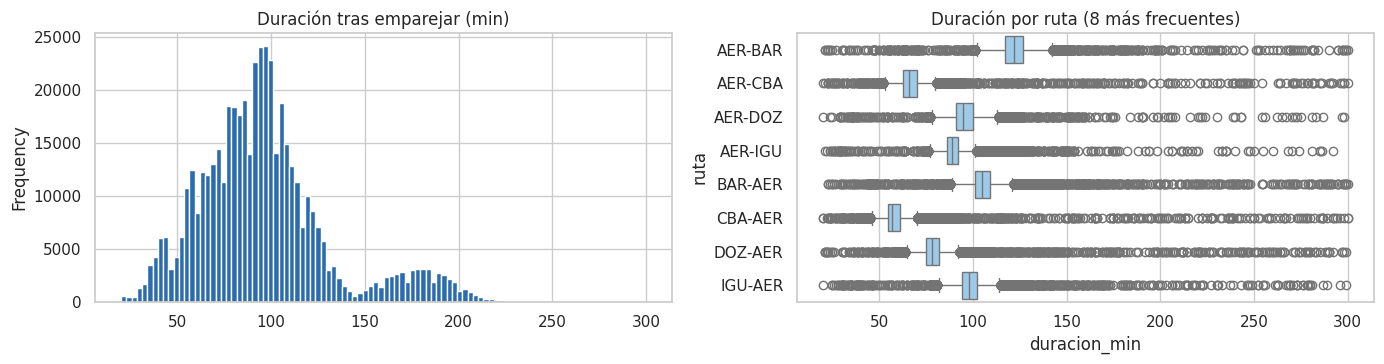

Resumen de la limpieza de vuelos:


,paso,registros_antes,registros_despues,eliminados
0,Nulos / fechas inválidas en campos clave,3335560,3335556,4
1,Duplicados exactos,3335556,3327495,8061
2,"No doméstico (internacional, etc.)",3327495,2704010,623485
3,"Clase de vuelo no comercial (privado, trabajo ...",2704010,1614825,1089185
4,Movimientos que no involucran a AER,1614825,1031079,583746
5,Emparejamiento despegue-aterrizaje (la unidad ...,515880,484366,31514
6,"Duración fuera de [20, 300] min",484366,484366,0
7,"Duración fuera de [0.5, 2.0] x mediana de la ruta",484366,481408,2958


Vuelos resultantes: 481408 | rutas distintas: 92


In [14]:
# 7. Validación de duraciones: rango global y relativo a la mediana de cada ruta
vuelos["ruta"] = vuelos["origen"] + "-" + vuelos["destino"]

fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
vuelos["duracion_min"].plot.hist(bins=100, ax=ax[0], color="#2b6cb0")
ax[0].set_title("Duración tras emparejar (min)")
top = vuelos["ruta"].value_counts().head(8).index
sns.boxplot(data=vuelos[vuelos["ruta"].isin(top)], y="ruta", x="duracion_min", ax=ax[1], color="#90cdf4")
ax[1].set_title("Duración por ruta (8 más frecuentes)")
plt.tight_layout(); plt.show()

n = len(vuelos)
vuelos = vuelos[vuelos["duracion_min"].between(MIN_DUR, MAX_DUR)]
registrar(f"Duración fuera de [{MIN_DUR}, {MAX_DUR}] min", n, len(vuelos))

med = vuelos.groupby("ruta")["duracion_min"].transform("median")
n = len(vuelos)
vuelos = vuelos[(vuelos["duracion_min"] >= FACTOR_MIN * med) & (vuelos["duracion_min"] <= FACTOR_MAX * med)].copy()
registrar(f"Duración fuera de [{FACTOR_MIN}, {FACTOR_MAX}] x mediana de la ruta", n, len(vuelos))

vuelos["sentido"] = np.where(vuelos["origen"] == AP_REF, "sale_AER", "llega_AER")
vuelos = vuelos.reset_index(drop=True)

print("Resumen de la limpieza de vuelos:")
display(pd.DataFrame(log))
print("Vuelos resultantes:", len(vuelos), "| rutas distintas:", vuelos["ruta"].nunique())

## 5. Integración con clima y construcción del target

**Clima.** El SMN es **diario**, por lo que el cruce se hace por **fecha local**, usando el día del momento en que el vuelo toca AER: **despegue** si AER es el origen, **aterrizaje** si AER es el destino. Se completa la serie diaria y se interpolan linealmente huecos de hasta 2 días (salvo la precipitación).

**Target.** `duracion_anomala = 1` si la duración supera el **P90 de la ruta**. Los umbrales se calculan únicamente con el primer 80 % cronológico de los vuelos para evitar fuga de información hacia el período de prueba.

In [15]:
# 8. Clima: serie diaria completa + interpolación de huecos cortos
w = smn_raw.dropna(subset=["fecha_clima"]).drop_duplicates("fecha_clima").set_index("fecha_clima").sort_index()[VARS_CLIMA]
w = w.resample("D").asfreq()

nulos_antes = w.isna().sum()
cont = [c for c in VARS_CLIMA if c != "precip"]
w[cont] = w[cont].interpolate(method="linear", limit=2, limit_area="inside")
nulos_despues = w.isna().sum()
display(pd.DataFrame({"nulos_antes": nulos_antes, "nulos_despues": nulos_despues}))

w = w.reset_index()
w["fecha_clima"] = w["fecha_clima"].astype("datetime64[ns]")

# 9. Join por fecha local del momento en que el vuelo toca AER
v = vuelos.copy()
t_ref = v["dt_salida"].where(v["origen"] == AP_REF, v["dt_llegada"])
v["fecha_clima"] = (t_ref + UTC_A_LOCAL).dt.normalize().astype("datetime64[ns]")
v = v.merge(w, on="fecha_clima", how="left")

sin_clima = v[VARS_CLIMA].isna().all(axis=1)
print("Vuelos sin ningún dato climático (fecha fuera del período del SMN):", int(sin_clima.sum()))
n = len(v)
v = v[~sin_clima]
registrar("Sin dato climático del día (fuera del período SMN o hueco largo)", n, len(v))
v = v.sort_values("dt_salida").reset_index(drop=True)
print("Vuelos con clima asociado:", len(v), "| nulos restantes por variable:")
print(v[VARS_CLIMA].isna().sum().to_dict())

,nulos_antes,nulos_despues
tmax,0,0
tmin,0,0
tmedia,0,0
precip,1381,1381
helio,331,320
vto_dir,0,0
vto_max,0,0
vel_med,0,0
pre_est,0,0
hum_rel,0,0


Vuelos sin ningún dato climático (fecha fuera del período del SMN): 120277
Vuelos con clima asociado: 361131 | nulos restantes por variable:
{'tmax': 0, 'tmin': 0, 'tmedia': 0, 'precip': 239575, 'helio': 78063, 'vto_dir': 0, 'vto_max': 0, 'vel_med': 0, 'pre_est': 0, 'hum_rel': 0, 'nub_tot': 0}


In [16]:
# 10. Target con umbral P90 por ruta, calculado solo con el período de entrenamiento
fecha_corte = v["dt_salida"].quantile(FRAC_TRAIN)
v["es_train"] = (v["dt_salida"] <= fecha_corte).astype(int)
print("Fecha de corte train/test:", fecha_corte)

stats = (v[v["es_train"] == 1].groupby("ruta")["duracion_min"]
           .agg(n_train="size", mediana_ruta_min="median", p90_ruta_min=lambda s: s.quantile(PCT_ANOMALO))
           .reset_index())
stats = stats[stats["n_train"] >= MIN_VUELOS_RUTA]
print(f"Rutas con >= {MIN_VUELOS_RUTA} vuelos de entrenamiento: {len(stats)} de {v['ruta'].nunique()}")

n = len(v)
v = v.merge(stats[["ruta", "mediana_ruta_min", "p90_ruta_min"]], on="ruta", how="inner")
registrar(f"Rutas con menos de {MIN_VUELOS_RUTA} vuelos de entrenamiento (umbral no confiable)", n, len(v))

v["duracion_anomala"] = (v["duracion_min"] > v["p90_ruta_min"]).astype(int)

# Variables de calendario (conocidas antes del vuelo), en hora local Argentina
loc = v["dt_salida"] + UTC_A_LOCAL
v["hora_salida_local"] = loc.dt.hour
v["dia_semana"]        = loc.dt.dayofweek
v["mes"]               = loc.dt.month
v["fin_de_semana"]     = (v["dia_semana"] >= 5).astype(int)

cols_final = ["dt_salida", "dt_llegada", "origen", "destino", "ruta", "sentido", "aerolinea", "aeronave", "pasajeros",
              "hora_salida_local", "dia_semana", "mes", "fin_de_semana", "mediana_ruta_min"] + VARS_CLIMA + \
             ["duracion_min", "p90_ruta_min", "duracion_anomala", "es_train"]
dataset = v[cols_final].sort_values("dt_salida").reset_index(drop=True)

print("\nResumen final de la limpieza:")
display(pd.DataFrame(log))
print("Dimensiones del dataset limpio:", dataset.shape)

Fecha de corte train/test: 2025-09-25 20:44:00
Rutas con >= 30 vuelos de entrenamiento: 76 de 90

Resumen final de la limpieza:


,paso,registros_antes,registros_despues,eliminados
0,Nulos / fechas inválidas en campos clave,3335560,3335556,4
1,Duplicados exactos,3335556,3327495,8061
2,"No doméstico (internacional, etc.)",3327495,2704010,623485
3,"Clase de vuelo no comercial (privado, trabajo ...",2704010,1614825,1089185
4,Movimientos que no involucran a AER,1614825,1031079,583746
5,Emparejamiento despegue-aterrizaje (la unidad ...,515880,484366,31514
6,"Duración fuera de [20, 300] min",484366,484366,0
7,"Duración fuera de [0.5, 2.0] x mediana de la ruta",484366,481408,2958
8,Sin dato climático del día (fuera del período ...,481408,361131,120277
9,Rutas con menos de 30 vuelos de entrenamiento ...,361131,360998,133


Dimensiones del dataset limpio: (360998, 29)


### Sobre el desbalance de clases
Por construcción (P90 por ruta) se espera ~10 % de vuelos anómalos en el período de entrenamiento. **No se aplica ningún remuestreo al dataset que se guarda**: el balanceo (`class_weight="balanced"` o SMOTE) debe aplicarse **solo sobre el conjunto de entrenamiento** en la etapa de modelado, para no contaminar el conjunto de prueba con muestras sintéticas.

## 6. Descripción del dataset luego de la limpieza y el preprocesamiento

In [17]:
print("Forma:", dataset.shape)
print("Período:", dataset["dt_salida"].min(), "->", dataset["dt_salida"].max())
print("Rutas:", dataset["ruta"].nunique(), "| aerolíneas:", dataset["aerolinea"].nunique(),
      "| modelos de aeronave:", dataset["aeronave"].nunique())
display(dataset.head())
dataset.info()

Forma: (360998, 29)
Período: 2021-03-15 21:07:00 -> 2026-08-01 02:03:00
Rutas: 76 | aerolíneas: 45 | modelos de aeronave: 97


,dt_salida,dt_llegada,origen,destino,ruta,sentido,aerolinea,aeronave,pasajeros,hora_salida_local,dia_semana,mes,fin_de_semana,mediana_ruta_min,tmax,tmin,tmedia,precip,helio,vto_dir,vto_max,vel_med,pre_est,hum_rel,nub_tot,duracion_min,p90_ruta_min,duracion_anomala,es_train
0,2021-03-15 21:07:00,2021-03-15 22:11:00,CBA,AER,CBA-AER,llega_AER,AEROLINEAS ARGENTINAS SA,EMB-ERJ190100IGW,87.0,18,0,3,0,57.0,25.8,21.3,23.0,2.0,3.8,2.0,31.0,9.0,1015.0,72.0,5.0,64.0,64.0,0,1
1,2021-03-16 00:56:00,2021-03-16 02:29:00,SAL,AER,SAL-AER,llega_AER,JETSMART AIRLINES S.A.,AIB-A320-232,129.0,21,0,3,0,102.0,25.8,21.3,23.0,2.0,3.8,2.0,31.0,9.0,1015.0,72.0,5.0,93.0,112.0,0,1
2,2021-03-16 02:20:00,2021-03-16 03:43:00,NEU,AER,NEU-AER,llega_AER,JETSMART AIRLINES S.A.,AIB-A320-232,116.0,23,0,3,0,81.0,24.5,21.0,22.3,2.0,0.0,18.0,41.0,16.0,1007.6,81.0,6.0,83.0,90.0,0,1
3,2021-03-16 08:42:00,2021-03-16 11:54:00,AER,USU,AER-USU,sale_AER,JETSMART AIRLINES S.A.,AIB-A320-232,137.0,5,1,3,0,196.0,24.5,21.0,22.3,2.0,0.0,18.0,41.0,16.0,1007.6,81.0,6.0,192.0,211.0,0,1
4,2021-03-16 09:56:00,2021-03-16 11:26:00,AER,DOZ,AER-DOZ,sale_AER,JETSMART AIRLINES S.A.,AIB-A320-232,111.0,6,1,3,0,95.0,24.5,21.0,22.3,2.0,0.0,18.0,41.0,16.0,1007.6,81.0,6.0,90.0,105.0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360998 entries, 0 to 360997
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   dt_salida          360998 non-null  datetime64[ns]
 1   dt_llegada         360998 non-null  datetime64[ns]
 2   origen             360998 non-null  object        
 3   destino            360998 non-null  object        
 4   ruta               360998 non-null  object        
 5   sentido            360998 non-null  object        
 6   aerolinea          360998 non-null  object        
 7   aeronave           360998 non-null  object        
 8   pasajeros          360998 non-null  float64       
 9   hora_salida_local  360998 non-null  int32         
 10  dia_semana         360998 non-null  int32         
 11  mes                360998 non-null  int32         
 12  fin_de_semana      360998 non-null  int64         
 13  mediana_ruta_min   360998 non-null  float64 

**Diccionario de variables del dataset limpio**

| Variable | Tipo | Descripción | ¿Usar como predictor? |
|---|---|---|---|
| `dt_salida`, `dt_llegada` | datetime (UTC) | Momento de despegue y aterrizaje | No (se usan para ordenar / split) |
| `origen`, `destino`, `ruta` | categórica | Aeropuertos y tramo `ORIGEN-DESTINO` | `ruta` sí |
| `sentido` | categórica | `sale_AER` / `llega_AER` | Sí |
| `aerolinea`, `aeronave` | categórica | Operador y **modelo** de aeronave | Sí |
| `pasajeros` | numérica | Pasajeros del vuelo (registro de despegue) | Sí (proxy de ocupación) |
| `hora_salida_local`, `dia_semana`, `mes`, `fin_de_semana` | numérica | Calendario (hora local Argentina) | Sí |
| `mediana_ruta_min` | numérica | Mediana histórica de la ruta (solo período train) | Sí (aproxima la longitud de la ruta) |
| `tmax`, `tmin`, `tmedia` | numérica (°C) | Temperaturas del día en AER | Sí |
| `precip` | numérica (mm) | Precipitación del día | Sí |
| `helio` | numérica (h) | Heliofanía (horas de sol) | Sí |
| `vto_dir`, `vto_max`, `vel_med` | numérica | Dirección, ráfaga máxima y velocidad media del viento | Sí |
| `pre_est`, `hum_rel`, `nub_tot` | numérica | Presión, humedad relativa y nubosidad total | Sí |
| `duracion_min` | numérica | Duración real del vuelo | **No** (el target se deriva de ella: fuga) |
| `p90_ruta_min` | numérica | Umbral P90 de la ruta | **No** (define el target) |
| **`duracion_anomala`** | binaria | **Target**: 1 si `duracion_min > p90_ruta_min` | — |
| `es_train` | binaria | 1 si pertenece al período de entrenamiento | Solo para el split |

In [18]:
num_cols = ["pasajeros", "hora_salida_local", "mediana_ruta_min"] + VARS_CLIMA + ["duracion_min"]
display(dataset[num_cols].describe().T)
print("\nNulos por columna (solo las que tienen):")
print(dataset.isna().sum()[lambda s: s > 0].to_dict())

print("\nDistribución del target:")
dist = dataset.groupby("es_train")["duracion_anomala"].agg(["size", "sum", "mean"]).rename(
    index={0: "test", 1: "train"}, columns={"size": "vuelos", "sum": "anómalos", "mean": "proporción"})
display(dist)

,count,mean,std,min,25%,50%,75%,max
pasajeros,360998.0,129.800157,44.022063,0.0,92.0,141.0,166.0,511.0
hora_salida_local,360998.0,13.416191,5.230330,0.0,9.0,13.0,18.0,23.0
mediana_ruta_min,360998.0,95.181790,34.016365,23.0,74.0,95.0,106.0,196.0
tmax,360998.0,22.304607,5.938382,5.7,17.5,22.7,27.0,38.5
tmin,360998.0,15.156042,5.432470,1.4,10.9,15.5,19.4,28.3
tmedia,360998.0,18.600845,5.499052,4.4,14.1,18.8,23.1,32.3
precip,121516.0,8.716059,16.418851,0.0,0.0,2.0,8.5,112.0
helio,283004.0,7.081600,3.950466,0.0,4.1,8.3,9.9,13.8
vto_dir,360998.0,15.505812,9.690457,1.0,9.0,12.0,20.0,36.0
vto_max,360998.0,37.250827,9.978793,13.0,30.0,37.0,43.0,104.0



Nulos por columna (solo las que tienen):
{'precip': 239482, 'helio': 77994}

Distribución del target:


,vuelos,anómalos,proporción
es_train,,,
test,72155,6965,0.096528
train,288843,26104,0.090374


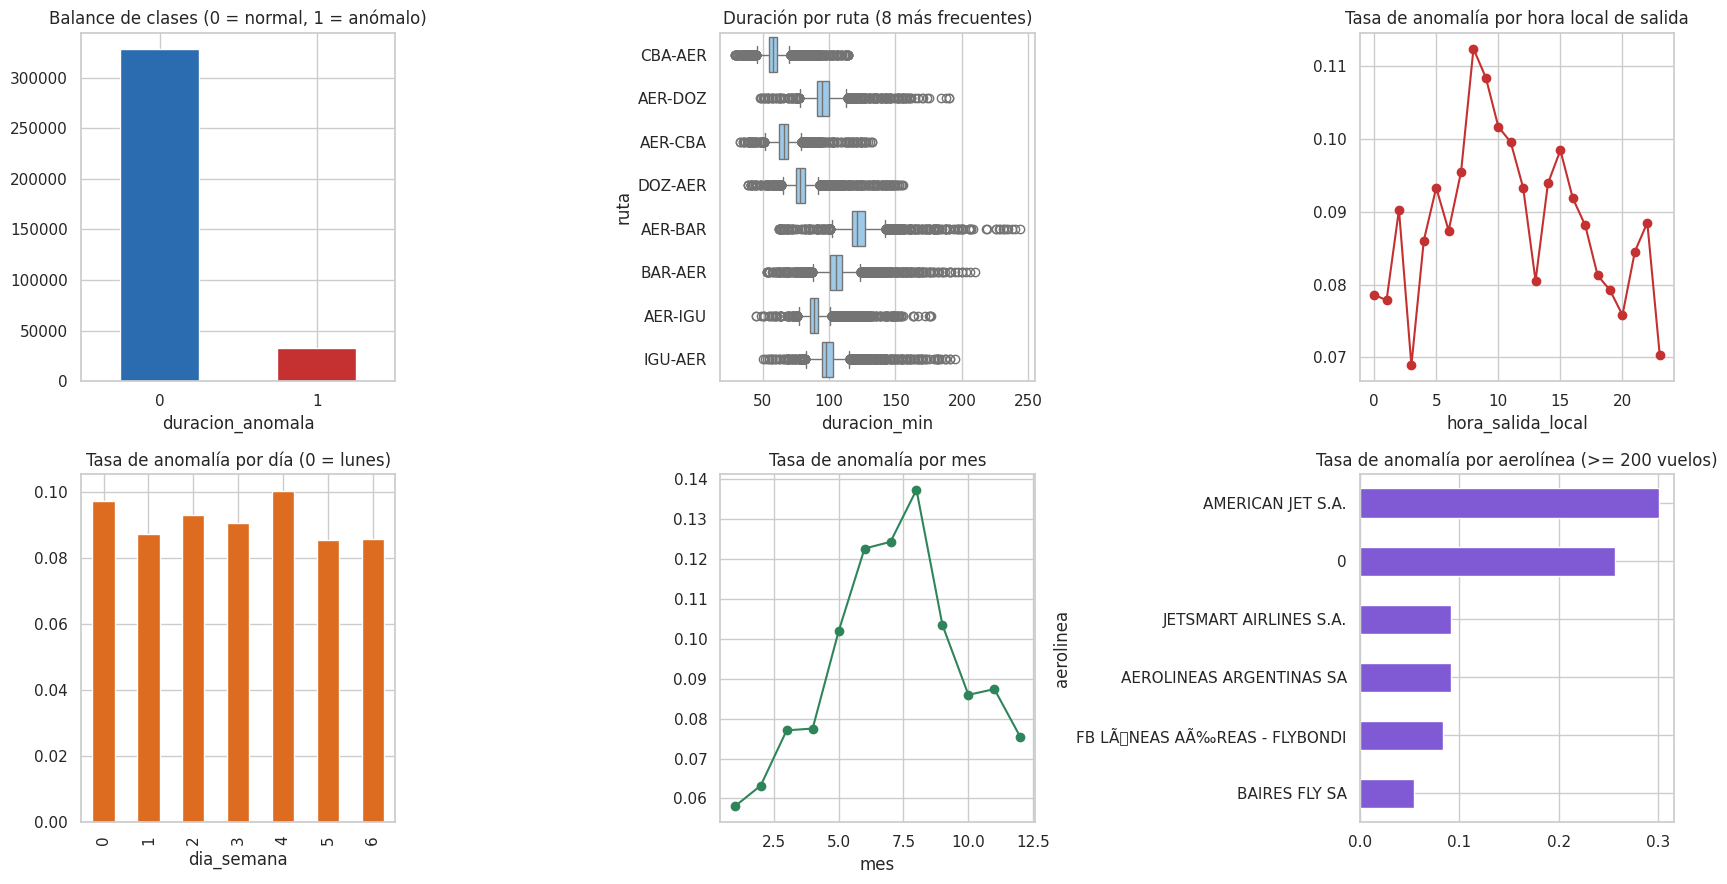

In [19]:
fig, ax = plt.subplots(2, 3, figsize=(17, 9))

dataset["duracion_anomala"].value_counts().sort_index().plot.bar(ax=ax[0, 0], color=["#2b6cb0", "#c53030"])
ax[0, 0].set_title("Balance de clases (0 = normal, 1 = anómalo)"); ax[0, 0].set_xticklabels(["0", "1"], rotation=0)

top = dataset["ruta"].value_counts().head(8).index
sns.boxplot(data=dataset[dataset["ruta"].isin(top)], y="ruta", x="duracion_min", ax=ax[0, 1], color="#90cdf4")
ax[0, 1].set_title("Duración por ruta (8 más frecuentes)")

dataset.groupby("hora_salida_local")["duracion_anomala"].mean().plot(ax=ax[0, 2], marker="o", color="#c53030")
ax[0, 2].set_title("Tasa de anomalía por hora local de salida")

dataset.groupby("dia_semana")["duracion_anomala"].mean().plot.bar(ax=ax[1, 0], color="#dd6b20")
ax[1, 0].set_title("Tasa de anomalía por día (0 = lunes)")

dataset.groupby("mes")["duracion_anomala"].mean().plot(ax=ax[1, 1], marker="o", color="#2f855a")
ax[1, 1].set_title("Tasa de anomalía por mes")

(dataset.groupby("aerolinea")["duracion_anomala"].agg(["mean", "size"]).query("size >= 200")["mean"]
        .sort_values().plot.barh(ax=ax[1, 2], color="#805ad5"))
ax[1, 2].set_title("Tasa de anomalía por aerolínea (>= 200 vuelos)")

plt.tight_layout(); plt.show()

Tasa de anomalía según día con/sin lluvia:


,size,mean
llueve,,
0,281389,0.085746
1,79609,0.112311


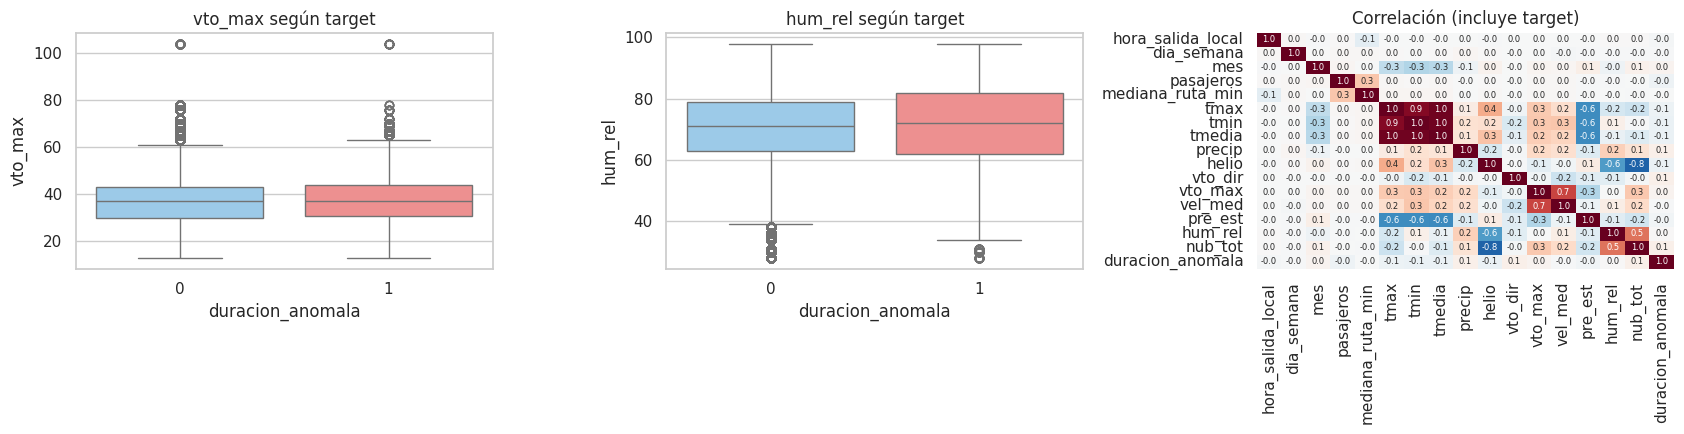

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for a, c in zip(ax[:2], ["vto_max", "hum_rel"]):
    sns.boxplot(data=dataset, x="duracion_anomala", y=c, ax=a, palette=["#90cdf4", "#fc8181"])
    a.set_title(f"{c} según target")

dataset["llueve"] = (dataset["precip"].fillna(0) > 0).astype(int)
print("Tasa de anomalía según día con/sin lluvia:")
display(dataset.groupby("llueve")["duracion_anomala"].agg(["size", "mean"]))

cc = ["hora_salida_local", "dia_semana", "mes", "pasajeros", "mediana_ruta_min"] + VARS_CLIMA + ["duracion_anomala"]
sns.heatmap(dataset[cc].corr(), annot=True, fmt=".1f", cmap="RdBu_r", center=0, ax=ax[2], cbar=False, annot_kws={"size": 6})
ax[2].set_title("Correlación (incluye target)")
plt.tight_layout(); plt.show()
dataset = dataset.drop(columns="llueve")

**Lectura de resultados (completar con los hallazgos de la corrida):**
- Balance del target y diferencia train/test.
- Franjas horarias, días, meses o aerolíneas con mayor tasa de anomalía.
- Relación (o falta de ella) entre viento/lluvia/nubosidad y el target. Una correlación lineal débil no descarta efectos no lineales o de interacción, que es lo que justifica un modelo basado en árboles.

## 7. Acceso al dataset limpio

In [ ]:
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
dataset.to_csv(OUT_PATH, index=False)
print("Dataset limpio guardado en:", OUT_PATH, "| filas:", len(dataset), "| columnas:", dataset.shape[1])

# Si los archivos están en el almacenamiento temporal de Colab, copiar también a Drive para no perder el resultado
if not DATA_DIR.startswith("/content/drive") and os.path.isdir("/content/drive/MyDrive"):
    destino = "/content/drive/MyDrive/TP_vuelos"
    os.makedirs(destino, exist_ok=True)
    dataset.to_csv(os.path.join(destino, "dataset_limpio.csv"), index=False)
    print("Copia también guardada en Drive:", destino)

**Enlace al dataset limpio:** `PEGAR_ACÁ_EL_LINK_DE_GOOGLE_DRIVE` *(Drive → clic derecho sobre `dataset_limpio.csv` → Compartir → "Cualquier persona con el enlace")*

Lectura directa desde el enlace compartido (reemplazar `FILE_ID` por el identificador del enlace):
```python
import pandas as pd
dataset = pd.read_csv("https://drive.google.com/uc?id=FILE_ID", parse_dates=["dt_salida", "dt_llegada"])
```

## 8. Modelo de Aprendizaje Automático propuesto

### Tipo de problema
Clasificación supervisada **binaria** y **desbalanceada** (~10 % de la clase positiva), con predictores **mixtos**: categóricos (`ruta`, `aerolinea`, `aeronave`, `sentido`), numéricos de calendario y numéricos meteorológicos, algunos con valores faltantes (p. ej. `precip`, `pasajeros`).

### Modelo elegido: Gradient Boosting sobre árboles (`HistGradientBoostingClassifier`)
| Criterio | Por qué encaja |
|---|---|
| Datos tabulares mixtos | Los árboles potenciados son el estado del arte en datos tabulares y manejan categóricas de forma nativa, sin one-hot masivo. |
| Relaciones no lineales e interacciones | La anomalía depende de interacciones (viento fuerte **y** lluvia **y** hora pico **y** ruta concreta) que un modelo lineal no captura. |
| Valores faltantes | Maneja `NaN` de forma nativa, sin imputar. |
| Robustez | No requiere escalar variables y tolera valores atípicos. |
| Desbalance | Admite `class_weight="balanced"`; evita depender de SMOTE sobre variables categóricas. |
| Escala | La versión basada en histogramas es rápida con cientos de miles de filas. |
| Interpretabilidad | Permite importancia por permutación para comunicar qué factores explican las anomalías a equipos de operaciones. |

### Baselines de comparación
`DummyClassifier` (piso de referencia) y **regresión logística** (modelo lineal interpretable). Si el boosting no supera claramente a la logística, la complejidad extra no se justifica.

### Protocolo de evaluación
- **Split temporal** (train = primeros meses, test = últimos), no aleatorio: en producción siempre se predice el futuro.
- Métricas: **PR-AUC (average precision)** como principal, más recall y F1 de la clase anómala y ROC-AUC. **La accuracy no sirve**: con 10 % de positivos, predecir siempre "normal" da ~90 %.
- El umbral de decisión se elegirá según el costo operativo de un falso negativo frente a un falso positivo.

La celda siguiente es una **prueba de factibilidad** con la configuración por defecto, no el modelo final.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

cat = ["ruta", "sentido", "aerolinea", "aeronave"]
num = ["pasajeros", "hora_salida_local", "dia_semana", "mes", "fin_de_semana", "mediana_ruta_min"] + VARS_CLIMA

tr, te = dataset[dataset["es_train"] == 1], dataset[dataset["es_train"] == 0]
Xtr, ytr, Xte, yte = tr[cat + num], tr["duracion_anomala"], te[cat + num], te["duracion_anomala"]
print(f"train: {len(tr):,} (anómalos {ytr.mean():.1%}) | test: {len(te):,} (anómalos {yte.mean():.1%})")

pre_hgb = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1,
                           encoded_missing_value=-1, min_frequency=20), cat),
    ("num", "passthrough", num)])
pre_lin = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), cat),
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num)])

modelos = {
    "Dummy (siempre normal)": Pipeline([("p", pre_lin), ("m", DummyClassifier(strategy="prior"))]),
    "Regresión logística": Pipeline([("p", pre_lin),
                                     ("m", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
    "HistGradientBoosting": Pipeline([("p", pre_hgb),
        ("m", HistGradientBoostingClassifier(categorical_features=[True]*len(cat) + [False]*len(num),
                                             class_weight="balanced", random_state=SEED))]),
}

res = []
for nombre, m in modelos.items():
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 1]
    res.append({"modelo": nombre, "PR-AUC": average_precision_score(yte, p), "ROC-AUC": roc_auc_score(yte, p)})
res = pd.DataFrame(res).set_index("modelo").round(3)
res.loc["(referencia: prevalencia en test)", "PR-AUC"] = round(yte.mean(), 3)
display(res)

mejor = modelos["HistGradientBoosting"]
print(classification_report(yte, (mejor.predict_proba(Xte)[:, 1] >= 0.5).astype(int),
                            target_names=["normal", "anómalo"], digits=3))

### Conclusiones y próximos pasos
- Completar con los resultados de la corrida: ¿el boosting supera a la logística y al baseline en PR-AUC?
- Próximos pasos: ajuste de hiperparámetros con validación cruzada temporal (`TimeSeriesSplit`), comparación con SMOTE aplicado solo a train, selección del umbral de decisión según costo operativo e importancia por permutación.

### Limitaciones
- **El emparejamiento despegue-aterrizaje es aproximado**: sin matrícula ni número de vuelo, se usa ruta + aerolínea + modelo (+ pasajeros). Los filtros de duración reducen el ruido, pero puede haber pares erróneos.
- El clima es **diario** y solo de AER: no distingue el momento del día en que llovió o ventó, y para vuelos que llegan a AER describe condiciones que en producción serían un pronóstico. El SMN diario no incluye visibilidad.
- El target es relativo al histórico de la ruta y mide duración inusual, no demora respecto del horario programado.